#### This interactive Python notebook is about your assignment (course work) to do some data analysis about sampled data regarding the key elements and ingredients leading to high quality red wines. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

#### Task 1: Import the data as of the Excel file "winequality-red.cvs". Subsequently, write the code that displays the number of rows and columns in your imported data sample. [1 Mark]

In [2]:
from google.colab import files
uploaded = files.upload()

Saving winequality-red.xlsx to winequality-red.xlsx


In [3]:
import io
winedata = pd.read_excel(io.BytesIO(uploaded['winequality-red.xlsx']))

In [4]:
print("number of rows : ",len(winedata))

number of rows :  1599


In [5]:
print("number of columns : ",len(winedata.columns))

number of columns :  12


#### Task 2: Write the code and type in the answer to the question “which are the three top independent (feature) variables with the least spread of data values?”. [1 Mark]

In [6]:
winedata_x = winedata.drop(labels='quality', axis=1)

In [7]:
(winedata_x.max() - winedata_x.min()).sort_values(axis=0, ascending=True)  #[:3]

density                   0.01362
chlorides                 0.59900
citric acid               1.00000
pH                        1.27000
volatile acidity          1.46000
sulphates                 1.67000
alcohol                   6.50000
fixed acidity            11.30000
residual sugar           14.60000
free sulfur dioxide      71.00000
total sulfur dioxide    283.00000
dtype: float64

---


*⚡ Answer :  density,  chlorides,  citric acid*

---



#### Task 3: Write the code to generate and display the correlation matrix among all 12 variables (feature and target variables). Subsequently, answer the question about the top three feature variables, which appear to have the strongest correlation with the target variable “quality”. [3 Marks]

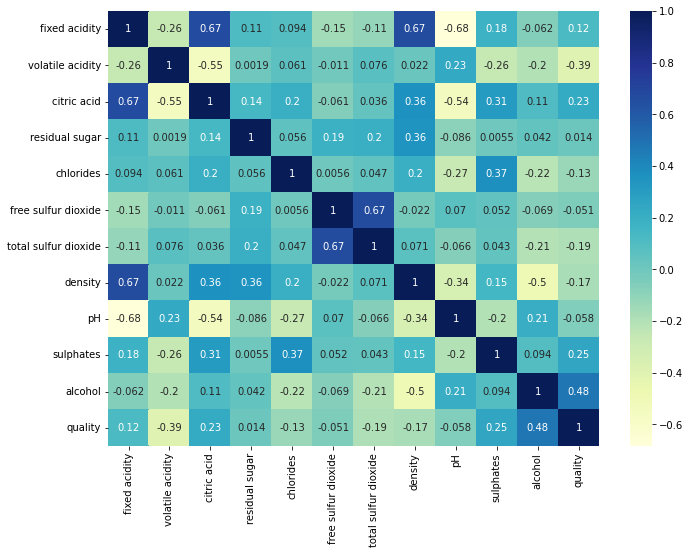

In [8]:
f, ax = plt.subplots(figsize=(11, 8))
corr = winedata.corr()

ax = sns.heatmap(corr, 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values,
            annot=True,
            cmap="YlGnBu")



---


*⚡ Answer :*  

alcohol, sulphate, citric acid

---


#### Task 4: Write the code to examine which variables do follow the normal (Gaussian) distribution. Subsequently, provide and justify your answer based on your observations. [3 Marks]

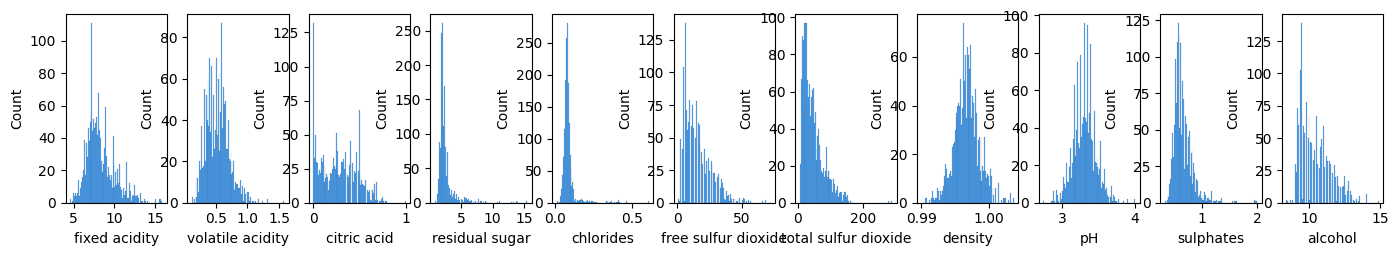

In [9]:
fig, axes = plt.subplots(1, 11, figsize=(17,2.5), dpi=100)
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:pink', 'tab:olive','tab:red', 'tab:blue', 'tab:green', 'tab:pink', 'tab:olive','dodgerblue']

for col in range (11):
  col_name = winedata.columns[col]
  ax=axes[col]
  sns.histplot(winedata[col_name] , color='dodgerblue', ax=ax, label=col_name, bins=100)



---


*⚡ Answer : pH and density variabels almost follow the gaussian distribution. If we carefully consider, the histplot of chlorides allso follow the gaussian distribution with a right tail.*

---



#### Task 5: Modify the given code such that a Principal Component Analysis (PCA) is carried out for all feature (independent) variables. Subsequently, draw a Scree plot to explain the ratio of variance as well as modify the given code to answer the question “which feature variables mostly contribute to the observed variance distribution by more than 30%”. [5 Marks]

In [10]:
from sklearn.decomposition import PCA
pca = PCA()

vals = winedata_x.values
pca.fit(vals)
wines_pca = pca.transform(vals)

Text(0, 0.5, 'PC 2')

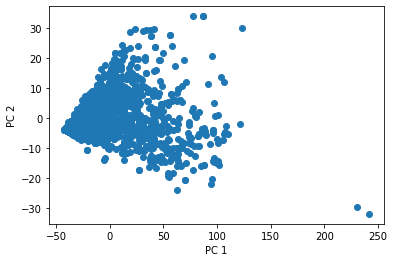

In [11]:
ax = plt.gca()
ax.scatter(wines_pca[:,0], wines_pca[:,1])
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')

In [12]:
pca.explained_variance_ratio_

array([9.46576976e-01, 4.83683046e-02, 2.58917183e-03, 1.51896798e-03,
       8.73553990e-04, 3.45607218e-05, 1.93627614e-05, 9.47278079e-06,
       8.41376628e-06, 1.21472798e-06, 4.68762788e-10])

[Text(0, 0, 'PC0'),
 Text(0, 0, 'PC1'),
 Text(0, 0, 'PC2'),
 Text(0, 0, 'PC3'),
 Text(0, 0, 'PC4'),
 Text(0, 0, 'PC5'),
 Text(0, 0, 'PC6'),
 Text(0, 0, 'PC7'),
 Text(0, 0, 'PC8'),
 Text(0, 0, 'PC9'),
 Text(0, 0, 'PC10')]

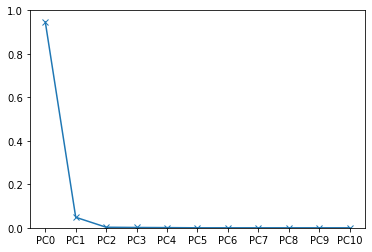

In [13]:
ax = plt.gca()
expl_var = pca.explained_variance_ratio_
ax.plot(expl_var, marker='x')
ax.set_ylim(0,1.)
ax.set_xticks([i for i in range(11)])
ax.set_xticklabels(["PC{}".format(i) for i in range(11)])

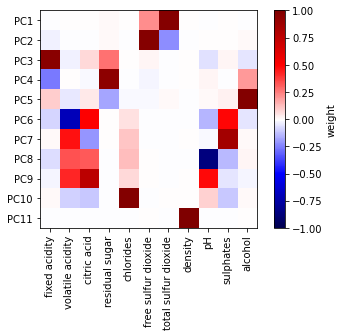

In [14]:
X_feature_names = winedata.columns
comps = pca.components_
ax = plt.gca()
img = ax.imshow(comps, cmap='seismic', vmin=-1, vmax=1)
plt.colorbar(img, label="weight")
ax.set_yticks([i for i in range(11)])
t = ax.set_yticklabels(["PC{}".format(i+1) for i in range(11)])
ax.set_xticks([i for i in range(11)])
t = ax.set_xticklabels(X_feature_names, rotation=90)

In [15]:
pca.components_[0,:]

array([-6.13247431e-03,  3.84465551e-04,  1.70902595e-04,  8.64894648e-03,
        6.37307290e-05,  2.18857434e-01,  9.75678369e-01,  3.72498542e-06,
       -2.68008619e-04,  2.23381730e-04, -6.35846721e-03])

In [16]:
print(np.array(X_feature_names)[np.where(pca.components_[0,:] > 0.3)])

['total sulfur dioxide']


#### Task 6: Write/modify the code to repeat task 5, this time, however, this time with normalized values across all feature variables. Explain the observed differences and answer again the question: Which feature variables mostly contribute to the observed variance distribution by more than 30%? [5 Marks]

In [17]:
# Normalize feature variables
from sklearn import preprocessing as pp

In [18]:
ss = pp.StandardScaler()
X = winedata_x
ss.fit(X.values)
pca_norm = PCA()
pca_norm.fit(ss.transform(X.values))
wines_pca_norm = pca_norm.transform(ss.transform(X.values))

In [19]:
print(np.array(X_feature_names)[np.where(pca_norm.components_[0,:] > 0.3)[0]])

['fixed acidity' 'citric acid' 'density']


#### Task 7: Write/modify the code to calculate the following two empirical probabilities (e.g., all 1599 rows as sample data): a) Probability of red wine quality to be less than 5, i.e., P(X<5), b) Probability of red wine quality to be equal or greater than 8, i.e., P(X ≥ 8), X = “quality”. [4 Marks]

In [20]:
from matplotlib import pyplot
from numpy.random import normal
from numpy import hstack
from statsmodels.distributions.empirical_distribution import ECDF

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [21]:
ecdf = ECDF(winedata['quality'])

In [22]:
ecdf([4])[0]

0.039399624765478425

In [23]:
1-ecdf([7])[0]

0.011257035647279534

#### Task 8: Let us assume that French wine makers and producers claim that it is possible to produce next year 1,000,000 bottles of red wines, to be considered as a population, a) with an average of quality equal or greater than 7, b) the distribution of quality scores will not be equal. Write the code, which states the Null (Ho) and alternative (H1) hypotheses such that you either reject or accept these two claims, (a) and (b), with confidence values 98% and 95%, respectively, on the basis of evidence provided by your 1599 large sample data. [6 Marks]

In [24]:
import scipy.stats as st

In [25]:
mu = winedata['quality'].mean()
sigma = winedata['quality'].std()
N = 1599

zc = st.norm.ppf(.99)
error = zc*sigma/np.sqrt(N)

lower = mu - error
print(lower)

upper = mu + error
print(upper)

5.589040643710374
5.683004384432215


⚡ With the 98% of confidence interval, the null hypothesis cannot be accepted since the average value should be in between 5.589 and 5.683.

#### Task 9: Let us assume that you have a first attempt at estimating a simple linear regression model with all 11 predictor (feature) variables predicting the quality of red wine (target variable). The model should take the form: y = a + b1X1 + b2X2+….+b11X11, with a being the intercept and b1,…b11, the co-efficients. Assuming also that the values of the predictor variables are normalised, write the code, which will deliver an estimate of this model, i.e., intercept and coefficients, as well as an estimate of how fit is the model in terms of metrics such as R-square and the Mean Squared Error. [6 Marks]

In [26]:
# Normalize feature variables
from sklearn.preprocessing import StandardScaler
# X_features = X
# X_norm = StandardScaler().fit_transform(X)

In [27]:
# Normalize feature variables
from sklearn.preprocessing import StandardScaler
# X_features = X
StandardScaler().fit_transform(winedata.values)

array([[-0.52835961,  0.96187667, -1.39147228, ..., -0.57920652,
        -0.96024611, -0.78782264],
       [-0.29854743,  1.96744245, -1.39147228, ...,  0.1289504 ,
        -0.58477711, -0.78782264],
       [-0.29854743,  1.29706527, -1.18607043, ..., -0.04808883,
        -0.58477711, -0.78782264],
       ...,
       [-1.1603431 , -0.09955388, -0.72391627, ...,  0.54204194,
         0.54162988,  0.45084835],
       [-1.39015528,  0.65462046, -0.77526673, ...,  0.30598963,
        -0.20930812, -0.78782264],
       [-1.33270223, -1.21684919,  1.02199944, ...,  0.01092425,
         0.54162988,  0.45084835]])

In [28]:
from sklearn.linear_model import LinearRegression

# Build linear regression model using different variables as predictors of quality
# Split data into predictors X and output Y
predictors = ['fixed acidity', 'density', 'citric acid', 'chlorides', 'free sulfur dioxide', 'volatile acidity', 'pH', 'alcohol', 'sulphates', 'residual sugar', 'total sulfur dioxide']
X = winedata[predictors]
y = winedata['quality']

# Initialise and fit model
lm = LinearRegression()
model = lm.fit(X, y)

In [29]:
y_pred = model.predict(X)

In [30]:
# model evaluation
from sklearn.metrics import mean_squared_error, r2_score
def show_error(y, y_pred):
  mse=mean_squared_error(y,y_pred)
  print("MSE :", mse)

  rmse = np.sqrt(mean_squared_error(y, y_pred))
  print("RMSE :", rmse)

  r2 = r2_score(y, y_pred)
  print("R2 :", r2)

show_error(y, y_pred)

MSE : 0.4167671672214079
RMSE : 0.6455750670692045
R2 : 0.36055170303868844


In [31]:
print(f'alpha = {model.intercept_}')
print(f'betas = {model.coef_}')

alpha = 21.965208449453286
betas = [ 2.49905527e-02 -1.78811638e+01 -1.82563948e-01 -1.87422516e+00
  4.36133331e-03 -1.08359026e+00 -4.13653144e-01  2.76197699e-01
  9.16334413e-01  1.63312698e-02 -3.26457970e-03]


#### Task 10: Based on the result of task 9, you make now an attempt to improve your linear regression model by turning it into a polynomial expression, i.e., adding as parameters squared variables and/or their combinations. For instance, your model should take the form: y = a +b1X1 + b1X12 + b2X1X2 + ….+error. Write/modify the code such that different degrees up to 5 are tried out. In your attempts, you may opt for suppressing the Intercept. Subsequently, state your observations on how the performance of these models is improved in terms of the R-square metric. Finally, explain whether an improved performance, as measured by the R-square metric, can be trusted and suggest ways to prove this trust. [6 Marks]

In [32]:
# Splitting the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=0)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [34]:
PolynomialFeatures(degree=5, interaction_only=False, include_bias=False).fit_transform(X)

array([[7.40000000e+00, 9.97800000e-01, 0.00000000e+00, ...,
        1.41887440e+05, 2.53903840e+06, 4.54354240e+07],
       [7.80000000e+00, 9.96800000e-01, 0.00000000e+00, ...,
        2.03315788e+06, 5.23929146e+07, 1.35012511e+09],
       [7.80000000e+00, 9.97000000e-01, 4.00000000e-02, ...,
        8.32984560e+05, 1.95570288e+07, 4.59165024e+08],
       ...,
       [6.30000000e+00, 9.95740000e-01, 1.30000000e-01, ...,
        3.38560000e+05, 5.88800000e+06, 1.02400000e+08],
       [5.90000000e+00, 9.95470000e-01, 1.20000000e-01, ...,
        3.40736000e+05, 7.49619200e+06, 1.64916224e+08],
       [6.00000000e+00, 9.95490000e-01, 4.70000000e-01, ...,
        9.60180480e+05, 1.12021056e+07, 1.30691232e+08]])

In [35]:
for degree in [1, 2, 3, 4, 5]:
    model = make_pipeline(PolynomialFeatures(degree=degree, interaction_only=False, include_bias=False), LinearRegression())
    model.fit(X, y)
    y_pred = model.predict(X)
    print(f"\nErrors with degree {degree}")
    show_error(y, y_pred)
    # y_plot = model.predict(X_plot)
    # ax.plot(x_plot, y_plot, label=f"degree {degree}")


Errors with degree 1
MSE : 0.4167671672214078
RMSE : 0.6455750670692044
R2 : 0.36055170303868855

Errors with degree 2
MSE : 0.3684820847451169
RMSE : 0.6070272520613197
R2 : 0.43463578687847404

Errors with degree 3
MSE : 0.2451772004795016
RMSE : 0.49515371399142466
R2 : 0.6238231904264406

Errors with degree 4
MSE : 0.029632596326489825
RMSE : 0.17214121042472608
R2 : 0.9545345345175679

Errors with degree 5
MSE : 0.00014895868019604638
RMSE : 0.012204862973259732
R2 : 0.9997714518276379


In [ ]:
from statsmodels.distributions.empirical_distribution import ECDF

In [ ]:
ecdf = ECDF([3, 3, 1, 4])

In [ ]:
ecdf([3, 55, 0.5, 1.5])

array([0.75, 1.  , 0.  , 0.25])

In [ ]:
ecdf = ECDF([1, 1, 1, 1])

In [ ]:
ecdf([3, 55, 0.5, 1.5])

array([1., 1., 0., 1.])

In [ ]:
winedata.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
mu = 1.70
sigma = 0.20
zc = st.norm.ppf(.975)

error = zc*0.20/np.sqrt(100)

lower = mu - error
print(lower)

upper = mu + error
print(upper)

1.6608007203091988
1.7391992796908011
